# Layer 2 in practice: the haloes

This notebook executes the material of {doc}`../layer2_halos`: the halo field,
the variance and peak height, mass definitions, the mass function, the bias
and its consistency with the mass function, the concentration, the profiles,
the beyond-linear bias, and the derivatives of all of them.
It runs on a `pip install` of `ggah_mod` plus `matplotlib`; the last section
compares the two flavours when `classy` is installed, and is skipped otherwise.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # before the first ggah_mod import

import importlib.util
from importlib.metadata import version
import time

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import emu_hmf
import emu_pk
import ggah_mod
import ggah_mod.halos as H
from ggah_mod import ACCURATE, DIFFERENTIABLE
from ggah_mod.cosmology import PLANCK18, make_pk, sigma8
from ggah_mod.halos.beyond_linear_bias import beta_nl, table_at
from ggah_mod.halos.field import make_field, make_fields

HAVE_CLASS = importlib.util.find_spec("classy") is not None
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6.4, 4.0),
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"ggah_mod {version('ggah_mod')}, emu_pk {version('emu_pk')}, "
      f"emu_hmf {version('emu_hmf')}, jax {jax.__version__}; CLASS available: {HAVE_CLASS}")

ggah_mod 1.0.0, emu_pk 2.0.1, emu_hmf 1.2.0, jax 0.10.2; CLASS available: True


## The halo field

`make_field` runs the whole chain for one cosmology, one power spectrum and one
redshift. The flavour supplies the grids and the four model choices.

In [2]:
pk = make_pk("emu_pk")
field = make_field(PLANCK18, DIFFERENTIABLE, pk, z=0.0)

print("model choices:", field.mdef, field.hmf_model, field.bias_model, field.cm_model)
for name in ("m", "k", "sigma", "dlns", "nu", "dndm", "bias", "conc", "r_delta", "r_s",
             "pk_cb", "pk_lin"):
    print(f"  {name:8s} shape {tuple(getattr(field, name).shape)}")
print("u(k|M):", field.u_nfw().shape)

model choices: 200m tinker08_csst tinker10 bhattacharya13
  m        shape (256,)
  k        shape (512,)
  sigma    shape (256,)
  dlns     shape (256,)
  nu       shape (256,)
  dndm     shape (256,)
  bias     shape (256,)
  conc     shape (256,)
  r_delta  shape (256,)
  r_s      shape (256,)
  pk_cb    shape (512,)
  pk_lin   shape (512,)


u(k|M): (512, 256)


## Variance and peak height

$\sigma(M)$ is the top-hat variance of the cold spectrum at the Lagrangian
radius $R(M) = (3M/4\pi\bar\rho_{\rm cb})^{1/3}$, and $\nu = \delta_{\rm c}/\sigma$
with $\delta_{\rm c} = 1.686$.
$\sigma$ at $8\,h^{-1}$Mpc on the cold spectrum is not $\sigma_8$, which is
taken on the total matter.

nu = 1 at M* = 4.090e+12 h^-1 Msun;  delta_c = 1.686


sigma(M(R = 8 Mpc/h)) on P_cb = 0.80566; sigma8 on P_m = 0.80193


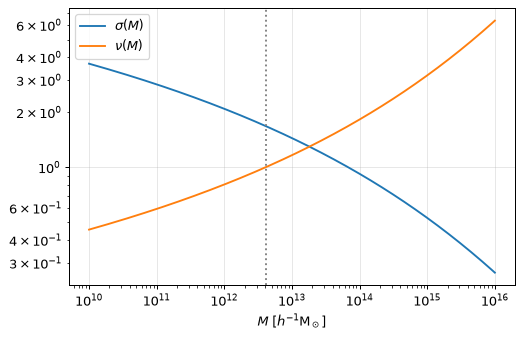

In [3]:
m = np.asarray(field.m)
i_star = int(np.argmin(np.abs(field.nu - 1.0)))
print(f"nu = 1 at M* = {m[i_star]:.3e} h^-1 Msun;  delta_c = {H.DELTA_C}")
R8_mass = float(H.mass_from_radius(8.0, PLANCK18.rho_cold))
print(f"sigma(M(R = 8 Mpc/h)) on P_cb = {float(H.sigma_of_mass(jnp.array([R8_mass]), field.k, field.pk_cb, PLANCK18.rho_cold)[0]):.5f}; "
      f"sigma8 on P_m = {float(sigma8(pk.pk(field.k, 0.0, PLANCK18), field.k)):.5f}")

fig, ax = plt.subplots()
ax.loglog(m, field.sigma, label=r"$\sigma(M)$")
ax.loglog(m, field.nu, label=r"$\nu(M)$")
ax.axvline(m[i_star], color="0.5", ls=":")
ax.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]")
ax.legend();

## Mass definitions

A $\Delta$-dependent fit is indexed by the overdensity with respect to the mean
matter density, $\Delta_{\rm m}$. For `200c`, `500c` and `vir` it runs with
redshift; `translate_mass` converts an NFW halo from one definition to another.

M_200m = 1e14, c = 5  ->  M_200c = 6.5054e+13, c_200c = 2.932


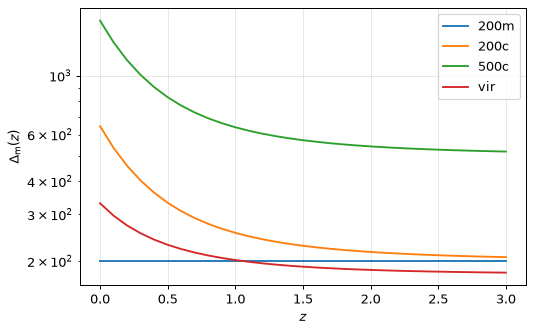

In [4]:
z = np.linspace(0.0, 3.0, 31)
fig, ax = plt.subplots()
for name in ("200m", "200c", "500c", "vir"):
    md = H.MassDef.from_string(name)
    ax.semilogy(z, [float(md.delta_mean(zi, PLANCK18)) for zi in z], label=name)
ax.set(xlabel="$z$", ylabel=r"$\Delta_{\rm m}(z)$")
ax.legend()

m200c, r200c, c200c = H.translate_mass(1e14, 5.0, "200m", "200c", 0.0, PLANCK18)
print(f"M_200m = 1e14, c = 5  ->  M_200c = {float(m200c):.4e}, c_200c = {float(c200c):.3f}")

## Abundance

All eighteen multiplicity functions of the registry, evaluated on the same
$\sigma(M)$ and shown against `tinker08_csst`, the default of both flavours.
They were calibrated at different halo definitions (see the table on the
layer page), so this compares the fits, not the physics.

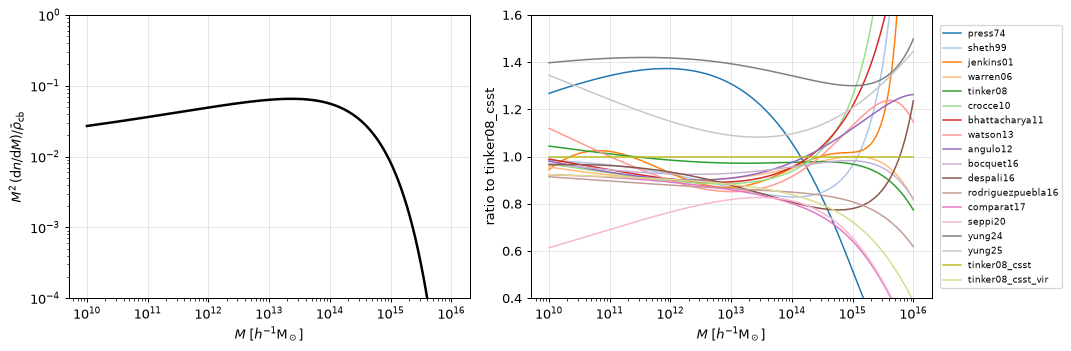

In [5]:
rho = PLANCK18.rho_cold
ref = field.dndm
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.0))
a0.loglog(m, m**2 * ref / rho, "k", lw=2, label="tinker08_csst")
colours = plt.cm.tab20(np.linspace(0, 1, 20))
for colour, name in zip(colours, H.MULTIPLICITY):
    kw = {"cosmo": PLANCK18} if name.startswith("tinker08_csst") else {}
    n = H.dndm(field.m, field.sigma, field.dlns, rho, model=name, z=0.0, **kw)
    a1.semilogx(m, n / ref, lw=1.2, color=colour, label=name)
a0.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]", ylabel=r"$M^2\,({\rm d}n/{\rm d}M)/\bar\rho_{\rm cb}$",
       ylim=(1e-4, 1))
a1.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]", ylabel="ratio to tinker08_csst", ylim=(0.4, 1.6))
a1.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()

## Bias, and the peak-background split

A mass function and a bias derived together are a pair. Weighting the mass
function by the bias should recover the mean density; over a finite mass range
both integrals below fall short of one and lose the same mass, so their ratio,
the mass-weighted mean bias, isolates the pairing.

dn/dM           b                 int b df    int df   ratio


press74         press74              0.843     0.648   1.301
sheth99         sheth99              0.622     0.471   1.321
tinker08        tinker10             0.701     0.518   1.355


bhattacharya11  bhattacharya11       0.643     0.491   1.309
despali16       sheth99              0.603     0.466   1.293
comparat17      comparat17           0.591     0.450   1.315
tinker08_csst   tinker10             0.715     0.525   1.363


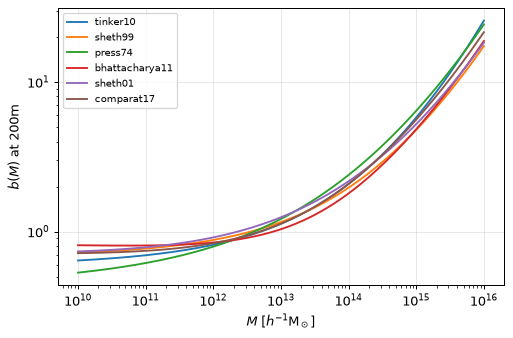

In [6]:
delta_m = float(H.MassDef.from_string("200m").delta_mean(0.0, PLANCK18))
print(f"{'dn/dM':16s}{'b':16s}{'int b df':>10s}{'int df':>10s}{'ratio':>8s}")
pairs = list(H.MATCHED_BIAS.items()) + [("tinker08_csst", "tinker10")]
for hmf, b_name in pairs:
    kw = {"cosmo": PLANCK18} if hmf.startswith("tinker08_csst") else {}
    n = H.dndm(field.m, field.sigma, field.dlns, rho, model=hmf, z=0.0, **kw)
    b = H.make_bias(b_name)(field.sigma, delta_m)
    bound = float(H.mass_fraction(field.m, n, rho))
    weighted = float(H.mass_weighted_bias(field.m, n, b, rho))
    print(f"{hmf:16s}{b_name:16s}{weighted:10.3f}{bound:10.3f}{weighted / bound:8.3f}")

fig, ax = plt.subplots()
for name in H.BIAS:
    ax.loglog(m, H.make_bias(name)(field.sigma, delta_m), label=name)
ax.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]", ylabel="$b(M)$ at 200m")
ax.legend(fontsize=8);

A fit asked for at a definition it was not calibrated in is refused, because
the error would be systematic rather than a tolerance.

In [7]:
try:
    make_field(PLANCK18, DIFFERENTIABLE, pk, mdef="200c")
except ValueError as err:
    print(err)

mass function 'tinker08_csst' was calibrated in 'SO 200m (Rockstar, Kun suite)', which covers MassDef(200, 'matter'); you asked for mdef='200c'.  These are different halo boundaries, so the number would be a systematic and not a tolerance -- the benchmark measured 81 percent for one such pairing.  Either request a definition the fit covers, choose a fit calibrated in this one, or pass calibration='warn' to take the mismatch knowingly.


## Concentration

Both flavours use `bhattacharya13`, a relation in peak height that reads the
growth factor off the power spectrum. `duffy08`, a power law in mass and
redshift, is the other relation calibrated at `200m`.

M = 9.73e+12: c = 8.620, r_200m = 0.5130, r_s = 0.0595 h^-1 Mpc (comoving)


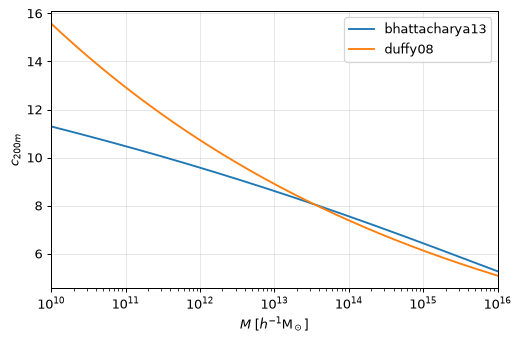

In [8]:
field_duffy = make_field(PLANCK18, DIFFERENTIABLE, pk, z=0.0, cm_model="duffy08")
fig, ax = plt.subplots()
ax.semilogx(m, field.conc, label="bhattacharya13")
ax.semilogx(m, field_duffy.conc, label="duffy08")
ax.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]", ylabel="$c_{200m}$", xlim=(1e10, 1e16))
ax.legend()
i13 = int(np.argmin(np.abs(m - 1e13)))
print(f"M = {m[i13]:.2e}: c = {float(field.conc[i13]):.3f}, r_200m = {float(field.r_delta[i13]):.4f}, "
      f"r_s = {float(field.r_s[i13]):.4f} h^-1 Mpc (comoving)")

## Profiles

The normalised Fourier transform of the NFW profile, $u(k|M)$, is one at small
$k$ and turns over near $k = 1/r_{\rm s}$. An Einasto profile with the same
scale radius and concentration is shown for comparison, and $\Delta\Sigma(R)$
of a $10^{13}\,h^{-1}{\rm M}_\odot$ halo from the analytic NFW projection.

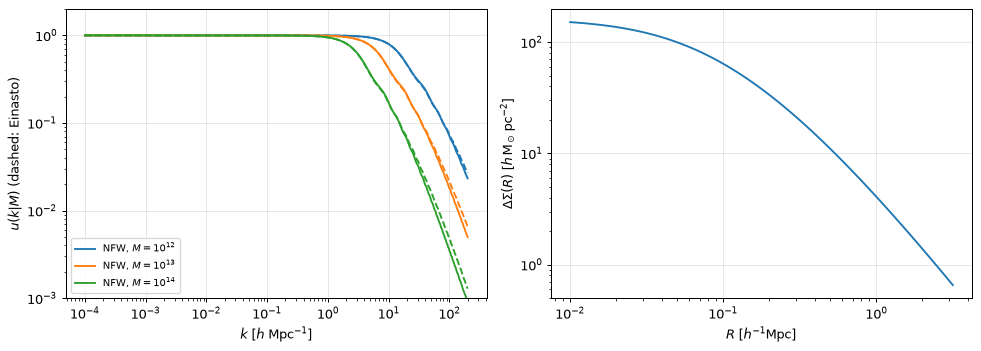

In [9]:
k = np.asarray(field.k)
u = field.u_nfw()
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.0))
for target in (1e12, 1e13, 1e14):
    i = int(np.argmin(np.abs(m - target)))
    line, = a0.loglog(k, u[:, i], label=f"NFW, $M = 10^{{{np.log10(m[i]):.0f}}}$")
    ein = H.einasto_uk(field.k, field.r_s[i:i + 1], field.conc[i:i + 1])[:, 0]
    a0.loglog(k, ein, ls="--", color=line.get_color())
a0.set(xlabel=r"$k$ [$h$ Mpc$^{-1}$]", ylabel=r"$u(k|M)$ (dashed: Einasto)", ylim=(1e-3, 2))
a0.legend(fontsize=8)

rho_s, r_s, r_200m = H.nfw_params_from_mass(1e13, field.conc[i13], 0.0, PLANCK18, mdef="200m")
R = np.logspace(-2, 0.5, 60)
a1.loglog(R, H.nfw_delta_sigma(R, rho_s, r_s) / 1e12)    # h Msun Mpc^-2 -> h Msun pc^-2
a1.set(xlabel=r"$R$ [$h^{-1}$Mpc]", ylabel=r"$\Delta\Sigma(R)$ [$h\,{\rm M}_\odot\,{\rm pc}^{-2}$]")
fig.tight_layout()

## Beyond-linear halo bias

The Mead & Verde table, rescaled to this cosmology from MultiDark, gives the
correction $1 + \beta^{\rm NL}(k, \nu_1, \nu_2)$ to the product of two linear
biases. It is applied to the two-halo term of the power spectra.
Below $k = 0.08\,h\,{\rm Mpc}^{-1}$ (`K_MIN_BNL`) it is tapered to zero, where
the measurement is consistent with zero; beyond the table's last wavenumber it is
held at its last value, where the one-halo term dominates.

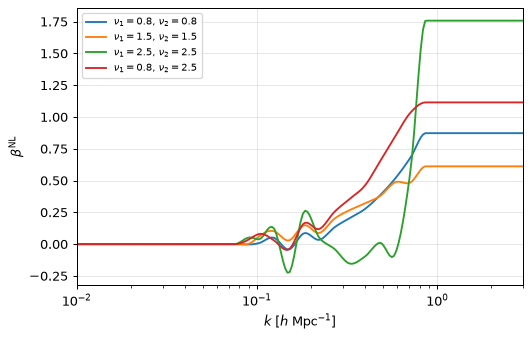

In [10]:
table = table_at(field.k, k=field.k, pk_cb=field.pk_cb)
nu = np.array([0.8, 1.5, 2.5])
beta = beta_nl(field.k, nu, nu, table)
fig, ax = plt.subplots()
for i, j in ((0, 0), (1, 1), (2, 2), (0, 2)):
    ax.semilogx(k, beta[:, i, j], label=rf"$\nu_1 = {nu[i]}$, $\nu_2 = {nu[j]}$")
ax.set(xlabel=r"$k$ [$h$ Mpc$^{-1}$]", ylabel=r"$\beta^{\rm NL}$", xlim=(1e-2, 3))
ax.legend(fontsize=8);

## Redshifts and derivatives

`make_fields` builds one field per redshift from a single spectrum call.

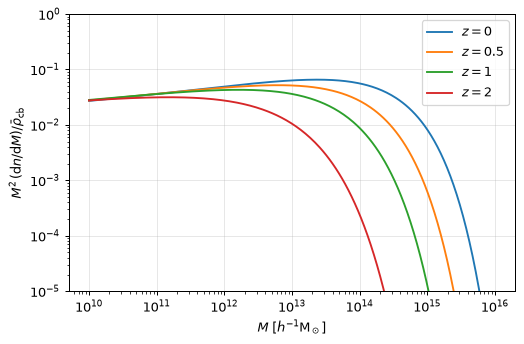

In [11]:
zs = np.array([0.0, 0.5, 1.0, 2.0])
fields = make_fields(PLANCK18, DIFFERENTIABLE, pk, zs)
fig, ax = plt.subplots()
for fz in fields:
    ax.loglog(m, m**2 * fz.dndm / rho, label=f"$z = {float(fz.z):g}$")
ax.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]", ylabel=r"$M^2\,({\rm d}n/{\rm d}M)/\bar\rho_{\rm cb}$",
       ylim=(1e-5, 1))
ax.legend();

The field is a pytree of differentiable leaves, so `jax.jacfwd` gives the
response of the mass function to each parameter at fixed mass, and `jax.jit`
compiles the whole chain.

jit: first call (compile) 1.3 s, next cosmology 22.0 ms


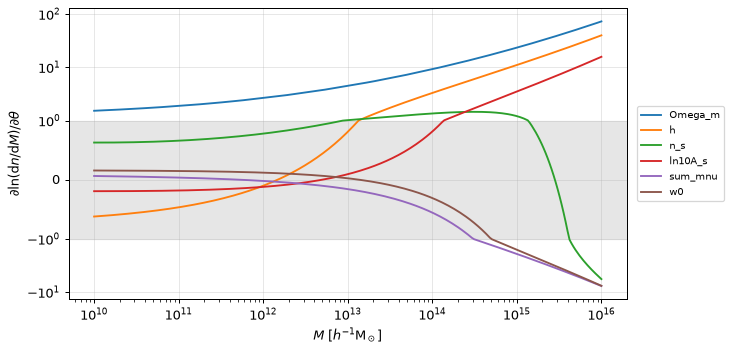

In [12]:
names = ["Omega_m", "h", "n_s", "ln10A_s", "sum_mnu", "w0"]
theta0 = jnp.array([float(getattr(PLANCK18, n)) for n in names])


def ln_dndm(theta):
    cc = PLANCK18.replace(**dict(zip(names, theta)))
    return jnp.log(make_field(cc, DIFFERENTIABLE, pk, z=0.0).dndm)


J = jax.jacfwd(ln_dndm)(theta0)
fig, ax = plt.subplots(figsize=(8.0, 4.2))
for i, name in enumerate(names):
    ax.semilogx(m, J[:, i], label=name)
ax.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]",
       ylabel=r"$\partial\ln({\rm d}n/{\rm d}M)/\partial\theta$")
ax.set_yscale("symlog", linthresh=1.0)
ax.axhspan(-1, 1, color="0.9", zorder=0)   # the symlog axis is linear inside the band
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5));

build = jax.jit(lambda c: make_field(c, DIFFERENTIABLE, pk, z=0.5).dndm)
t0 = time.perf_counter(); build(PLANCK18).block_until_ready(); t1 = time.perf_counter()
build(PLANCK18.replace(Omega_m=0.30)).block_until_ready(); t2 = time.perf_counter()
print(f"jit: first call (compile) {t1 - t0:.1f} s, next cosmology {1e3 * (t2 - t1):.1f} ms")

## The two flavours

`ACCURATE` differs from `DIFFERENTIABLE` in its power spectrum (CLASS at raised
precision instead of `emu_pk`) and in its grids; the model choices are the same.
The ratio below is that whole difference, on the differentiable mass grid.

dndm  max |DIFFERENTIABLE/ACCURATE - 1| below 1e15: 5.33e-03
bias  max |DIFFERENTIABLE/ACCURATE - 1| below 1e15: 1.52e-03
conc  max |DIFFERENTIABLE/ACCURATE - 1| below 1e15: 4.26e-04


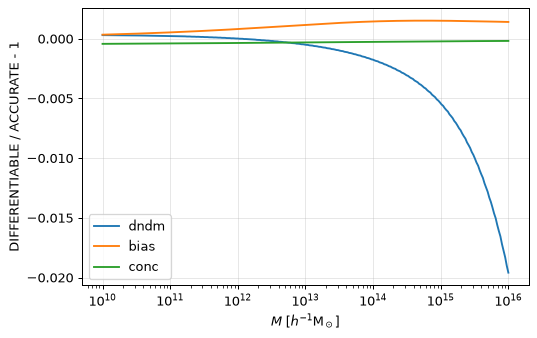

In [13]:
if HAVE_CLASS:
    acc = make_field(PLANCK18, ACCURATE, make_pk("class"), z=0.0)
    lm_a = np.log(np.asarray(acc.m))
    fig, ax = plt.subplots()
    for name in ("dndm", "bias", "conc"):
        a = np.exp(np.interp(np.log(m), lm_a, np.log(np.asarray(getattr(acc, name)))))
        ratio = np.asarray(getattr(field, name)) / a - 1
        ax.semilogx(m, ratio, label=name)
        print(f"{name:5s} max |DIFFERENTIABLE/ACCURATE - 1| below 1e15: "
              f"{np.max(np.abs(ratio[m < 1e15])):.2e}")
    ax.set(xlabel=r"$M$ [$h^{-1}{\rm M}_\odot$]", ylabel="DIFFERENTIABLE / ACCURATE - 1")
    ax.legend()
else:
    print("classy is not installed: pip install 'ggah_mod[reference]' to run this cell.")

## Things to try

- Build a field at $\Omega_k = 0.05$ and read the warning `tinker08_csst`
  emits; then ask for `mdef="vir"` at the same curvature.
- Replace the default pairing with `hmf_model="tinker08", bias_model="tinker10"`
  and compare the peak-background-split ratio with the table above.
- Compute the effective bias of all haloes above $10^{13}\,h^{-1}{\rm M}_\odot$
  with `field.effective_bias` and differentiate it with respect to
  $\sum m_\nu$.

Previous: {doc}`../layer1_cosmology` and its {doc}`notebook <layer1_cosmology>`.